# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: El dataset no contiene valores ausentes y los tipos de datos son correctos

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
dup_users = df.duplicated(subset='user_id').sum()
print('Duplicated Users: ',dup_users)

Duplicated Users:  0


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'converted', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Conteo de categorías:

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- converted ---
0    34294
1     5706
Name: converted, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**: 

Todas las columnas tienen valores esperados. La categoría `landing` solo contiene A y B (con un balance casi 50/50: 19,982 vs 20,018), `converted` es binaria (0/1), y las variables categóricas (region, dispositivo, traffic_source, user_type) no muestran categorías mal escritas ni duplicadas. Los datos están listos para el análisis.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t de Student (t-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** La pagina actual y la página nueva funcionan igual. No existe diferencia en el gasto promedio entre los usuarios que convirtieron en la página A y los que convirtieron en la página B
- **Hipótesis alternativa (H₁):** La página nueva funciona mejor que la actual. Existe una diferencia en el gasto promedio entre los usuarios que convirtieron en la página A y los que convirtieron en la página B

In [12]:
# Aplicar prueba
alpha = 0.05
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21


In [13]:
print("Gasto promedio A:", gasto_A.mean())
print("Gasto promedio B:", gasto_B.mean())

Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392


### 📝 Conclusión e interpretación

**Decisión:**  
Hay evidencia contra la hipòtesis nula (H₀). Rechazamos la hipótesis nula: hay evidencia de una diferencia. (`p < alpha`)

**Interpretación de negocio:**  
Entre los usuarios que se convirtieron, el gasto promedio en la página B `$68.75` fue mayor que en la página A `$61.09`, una diferencia de casi $7.66 por usuario. Dado que esta diferencia es estadísticamente significativa y no producto del azar, la página B genera un mayor valor económico por usuario convertido.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** La pagina actual y la página nueva funcionan igual. No existe asociación entre la versión de la página (A o B) y la conversión del usuario; la tasa de conversión es independiente de la versión mostrada.
- **Hipótesis alternativa (H₁):** La página nueva funciona mejor que la actual. Existe asociación entre la versión de la página y la conversión del usuario; la tasa de conversión depende de la versión mostrada.

In [14]:
# Número de usuarios convertidos por página
convertidos = df[df['converted'] == 1].groupby('landing')['user_id'].count()

# Total de usuarios por página
totales = df.groupby('landing')['user_id'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: user_id, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [15]:
# Tabla de contingencia: crosstab
tabla_conversion = pd.crosstab(df['landing'], df['converted'])
print(tabla_conversion)

converted      0     1
landing               
A          17470  2512
B          16824  3194


In [16]:
# Aplicar prueba
chi2, p_value, gl, esperado = chi2_contingency(tabla_conversion)

# Visualizar resultados
print(f"Estadístico : {chi2:.4f}")
print(f"Valor p: {p_value}")

Estadístico : 93.3748
Valor p: 4.327184295434911e-22


### 📝 Conclusión e interpretación

**Decisión:**  Se rechaza H₀. El valor p (4.33 × 10⁻²²) es muchísimo menor que alpha = 0.05 — la relación entre versión de página y conversión es estadísticamente significativa.

**Interpretación de negocio:**  
Calculando las tasas: A convirtió al `13 %` (2,512/19,982) y B al `16 %` (3,194/20,018)
La página B no solo genera más gasto promedio por usuario convertido, sino que también convierte a una proporción significativamente mayor de usuarios. Ambos resultados apuntan en la misma dirección: B es la versión superior.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión del usuario.
- **Hipótesis alternativa (H₁):** Existe asociación entre la fuente de tráfico y la conversión del usuario.

In [17]:
tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla_traffic)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [18]:
# Aplicar prueba
chi2_traffic, p_valor_traffic, gl_traffic, esperado_traffic = chi2_contingency(tabla_traffic)

print(f"Estadístico : {chi2_traffic:.4f}")
print(f"Valor p: {p_valor_traffic}")


Estadístico : 8.6621
Valor p: 0.0341375947833914


In [19]:
tasa_por_canal = df.groupby('traffic_source')['converted'].mean()
print(tasa_por_canal)

traffic_source
Ads         0.147382
Email       0.149927
Organic     0.137877
Referral    0.138812
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza H₀, aunque con un margen mucho más ajustado (p = 0.034 vs alpha = 0.05), apenas por debajo.
Existe asociación estadísticamente significativa entre la fuente de tráfico y la conversión, pero la evidencia es más débil

**Interpretación de negocio:**  
Aunque la asociación es estadísticamente significativa, la diferencia entre canales es baja. 
Email y Ads muestran una ligera ventaja en efectividad de conversión sobre Organic y Referral. Pero no amerita, por sí sola, reasignar recursos sin antes considerar también el costo de cada canal (Organic y Referral suelen ser más baratos de adquirir que Ads).

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe asociación entre el tipo de usuario y la conversión.

In [20]:
tabla_user_type = pd.crosstab(df['user_type'], df['converted'])
print(tabla_user_type)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [21]:
tasa_por_user_type = df.groupby('user_type')['converted'].mean()
print(tasa_por_user_type)

user_type
Nuevo         0.143587
Recurrente    0.140904
Name: converted, dtype: float64


In [22]:
# Aplicar prueba
chi2_user, p_valor_user, gl_user, esperado_user = chi2_contingency(tabla_user_type)

print(f"Estadístico : {chi2_user:.4f}")
print(f"Valor p: {p_valor_user}")


Estadístico : 0.5135
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza H₀. El valor p (0.474) es mucho mayor que alpha = 0.05, así que no hay evidencia suficiente para afirmar que existe asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
Las tasas de conversión de usuarios Nuevos `14.36%` y Recurrentes `14.09%` son prácticamente idénticas, y la prueba confirma que esta pequeña diferencia es explicable por azar. En otras palabras, el hecho de ser un usuario nuevo o recurrente no influye en la probabilidad de conversión dentro de este experimento. Ambos perfiles se comportan de manera similar.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

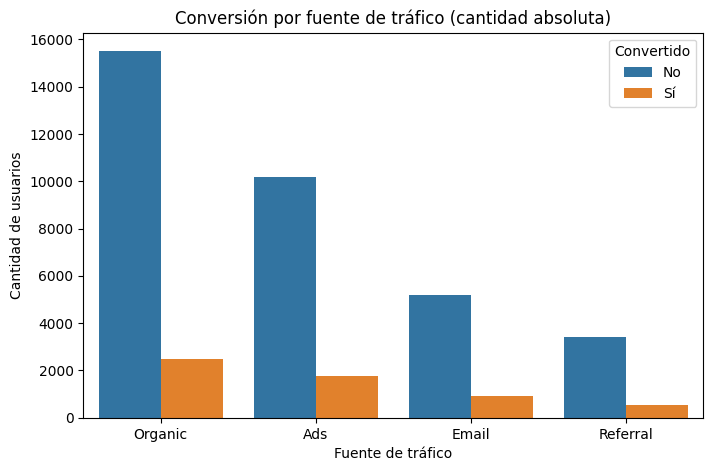

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='traffic_source', hue='converted', order=df['traffic_source'].value_counts().index)
plt.title('Conversión por fuente de tráfico (cantidad absoluta)')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Convertido', labels=['No', 'Sí'])
plt.show()

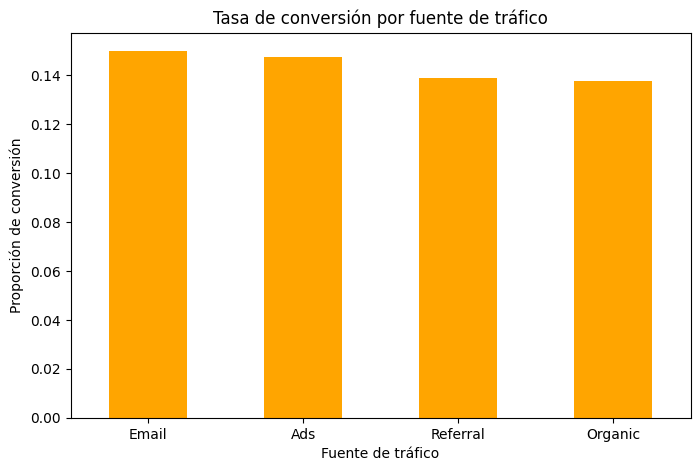

In [24]:
tasa_por_canal.sort_values(ascending=False).plot(kind='bar', figsize=(8,5), color='orange')
plt.title('Tasa de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción de conversión')
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: 
El gráfico de cantidades absolutas muestra que `Organic`, es el canal con más volumen de usuarios (17.9K), seguido de Ads. Sin embargo, el gráfico de tasas de conversión revela que Organic no es el canal más eficiente: `Email` 14.99% y `Ads` 14.74% convierten proporcionalmente mejor que `Organic` 13.79% y `Referral` 13.88%. 
Esto confirma de manera visual la prueba de chi-cuadrado del Paso 4: la diferencia es estadísticamente significativa pero modesta en magnitud.

### Relación entre el tipo de usuario y la conversión

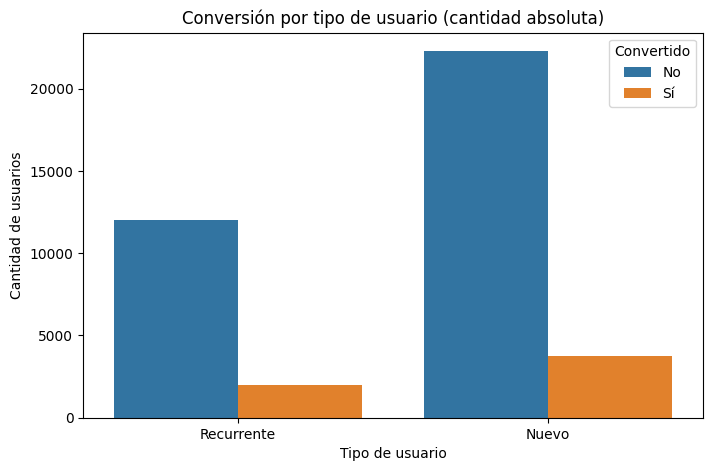

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Conversión por tipo de usuario (cantidad absoluta)')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Convertido', labels=['No', 'Sí'])
plt.show()

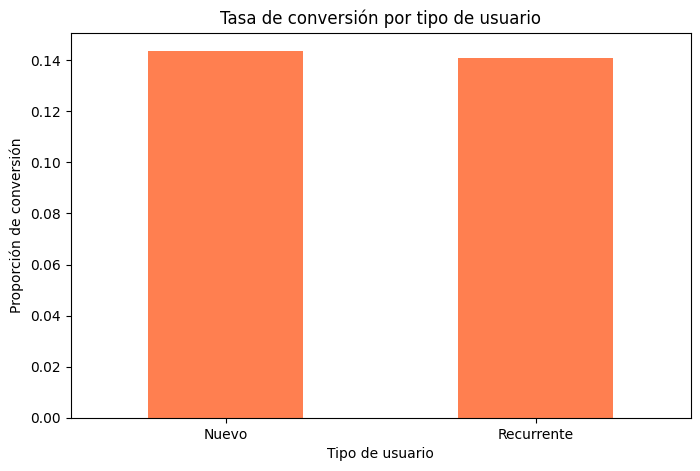

In [26]:
tasa_por_user_type.sort_values(ascending=False).plot(kind='bar', figsize=(8,5), color='coral')
plt.title('Tasa de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción de conversión')
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: 
El gráfico muestra que hay más usuarios Nuevos (26K) que Recurrentes (13.9k) en el experimento. En cuanto a la tasa de conversión, ambos grupos son prácticamente idénticos; 14.36% Nuevos vs 14.09% Recurrentes.
Lo cual es consistente con la prueba de chi-cuadrado del Paso 5 (p = 0.474): no hay evidencia de que el tipo de usuario influya en la probabilidad de conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La página B genera un gasto promedio de $68.75 por usuario convertido, frente a $61.09 en la página A.
- La diferencia es estadísticamente significativa (p ≈ 3.6e-21).
- **Interpretación:** los usuarios que compran en B gastan, en promedio, casi $7.7 más que los que compran en A.

<br>

**Tasa de conversión:** 

- La página B convierte al 15.96% de sus usuarios, frente a 12.6% en la página A.
- La diferencia es estadísticamente significativa (p ≈ 4.3e-22).
- **Interpretación:** B no solo genera más gasto por usuario, también convierte a una proporción notablemente mayor de visitantes en clientes.

---

#### 📊 **Segmentación por fuente de tráfico**

- Existe una asociación estadísticamente significativa entre `canal` y `conversión` (p = 0.034), aunque de magnitud modesta: `Email` (14.99%) y `Ads` (14.74%) convierten levemente mejor que `Organic` (13.79%) y `Referral` (13.88%).
- **Interpretación:** el canal de adquisición tiene algo de relevancia, pero es un factor secundario comparado con la versión de la página.
 
 ---

#### 📊 **Segmentación por tipo de usuario**

- No hay asociación estadísticamente significativa entre `tipo de usuario` y `conversión` (p = 0.474): Nuevos (14.36%) y Recurrentes (14.09%) se comportan de forma prácticamente idéntica.
- **Interpretación:** la estrategia de landing page no necesita diferenciarse entre usuarios nuevos y recurrentes.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Migrar el tráfico completo a la página B: genera de forma consistente mayor conversión y mayor gasto promedio, con resultados estadísticamente robustos.
- Priorizar inversión en canales Email y Ads sobre Organic y Referral cuando el objetivo sea maximizar la tasa de conversión, considerando también el costo de adquisición de cada canal.
- No es necesario personalizar la landing page por tipo de usuario (nuevo vs recurrente), ya que no influye en la conversión.